In [1]:
import os
import sys

# to setup import paths add project root dirs to sys.path
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
from baseVR.base_functionality import init_import_paths
init_import_paths()

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib qt
%matplotlib widget

from analytics_processing import analytics
import analytics_processing.analytics_constants as C
from CustomLogger import CustomLogger as Logger

from dashsrc.plot_components.plot_wrappers.data_selection import group_filter_data

from analytics_processing.modality_loading import session_modality_from_nas
from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args
from analytics_processing.sessions_from_nas_parsing import fullfnames2snames

# import GridSpecFromSubplotSpec
from matplotlib.gridspec import GridSpecFromSubplotSpec
import scipy.stats as stats
import statsmodels.api as sm
from matplotlib.colors import LinearSegmentedColormap, Normalize



In [3]:
output_dir = "./outputs/experimental/"
data = {}
nas_dir = C.device_paths()[0]
Logger().init_logger(None, None, logging_level="DEBUG")

In [4]:
animal_ids = [6]
paradigm_ids = [1100]
session_ids = None

In [5]:
session_dirs, _ = sessionlist_fullfnames_from_args(paradigm_ids, animal_ids, session_ids)
session_names = fullfnames2snames(session_dirs)

2026-02-27 15:01:19,933|DEBUG|211556|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2026-02-27 15:01:33,475|DEBUG|211556|sessions_from_nas_parsing|get_sessionlist_fullfnames
	For paradigms [1100], animals [6], found 34 sessions.
2026-02-27 15:01:33,478|DEBUG|211556|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: [1100], animal_ids: [6], session_ids: None, from_date: None, to_date: None
	Merging 34 sessions



In [6]:
fr_raw = analytics.get_analytics('FiringRate40msHz', session_names=session_names)


2026-02-27 15:01:33,522|DEBUG|211556|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-02-27 15:02:00,239|DEBUG|211556|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2026-02-27 15:02:00,241|DEBUG|211556|analytics|get_analytics
	Processing FiringRate40msHz, (6, 1100, 0) 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hdf5
/mnt/z/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min
2026-02-27 15:02:01,057|INFO|211556|analytics|get_analytics
	Analytic `FiringRate40msHz` not does not exist for (6, 1100, 0), compute first, or check for typo
2026-02-27 15:02:01,059|DEBUG|211556|analytics|get_analytics
	Processing FiringRate40msHz, (6, 1100, 1) 2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min.hdf5
/mnt/z/BMI/VirtualReality/SpatialSequenceLearning

In [7]:


fr = fr_raw.drop("from_ephys_timestamp", axis=1)
fr.index = fr.index.droplevel((0,1,3, ))
fr.set_index('to_ephys_timestamp', append=True, inplace=True)
fr['global_t'] = np.arange(40_000, 40_000*len(fr)+1, 40_000)
fr.set_index('global_t', append=True, inplace=True)
fr.index = fr.index.rename(['session_id', 'session_t', 'global_t'])
fr

Unit0001  Unit0002  Unit0003  Unit0004  \
session_id session_t  global_t                                              
1          40000      40000               0         0         0         0   
           80000      80000               0         0         0         0   
           120000     120000              0         0         0         0   
           160000     160000              0         0         0         0   
           200000     200000              0         0         0         0   
...                                     ...       ...       ...       ...   
33         4435960000 53320480000         0         0         0         0   
           4436000000 53320520000         0         0         0         0   
           4436040000 53320560000         0         0         0         0   
           4436080000 53320600000         0         0         0         0   
           4436120000 53320640000         0         0         0         0   

                                   Unit0005  Unit0006  Unit0007  Unit0008  \
session_id session_t  global_t                                              
1          40000      40000               0         0         0         0   
           80000      80000               0         0         0         0   
           120000     120000              0         0         0         0   
           160000     160000              0         0         0         0   
           200000     200000              0         0         0         0   
...                                     ...       ...       ...       ...   
33         4435960000 53320480000         0         0         0         0   
           4436000000 53320520000         0         0         0         0   
           4436040000 53320560000         0         0         0         0   
           4436080000 53320600000         0         0         0         0   
           4436120000 53320640000         0         0         0         0   

                                   Unit0009  Unit0010  ...  Unit0068  \
session_id session_t  global_t                         ...             
1          40000      40000               0         0  ...         0   
           80000      80000               0         0  ...         0   
           120000     120000              0         0  ...         0   
           160000     160000              0         0  ...         0   
           200000     200000              0         0  ...         0   
...                                     ...       ...  ...       ...   
33         4435960000 53320480000         0         0  ...        25   
           4436000000 53320520000         0         0  ...        25   
           4436040000 53320560000         0         0  ...        25   
           4436080000 53320600000         0         0  ...        25   
           4436120000 53320640000         0         0  ...         0   

                                   Unit0069  Unit0070  Unit0071  Unit0072  \
session_id session_t  global_t                                              
1          40000      40000               0         0         0         0   
           80000      80000               0         0         0         0   
           120000     120000              0         0         0         0   
           160000     160000              0         0         0         0   
           200000     200000              0         0         0         0   
...                                     ...       ...       ...       ...   
33         4435960000 53320480000         0         0        25         0   
           4436000000 53320520000         0         0        25         0   
           4436040000 53320560000        25         0        25         0   
           4436080000 53320600000         0         0         0         0   
           4436120000 53320640000         0        25         0         0   

                                   Unit0073  Unit0074  Unit0075  Unit0076  \
session_id sess

In [ ]:
action_enc_cols = [
    'frame_raw_500msMedian',                  # forward_velocity
    'frame_raw_abs_acc_500msMedian',          # forward_acceleration
    'frame_YawPitch_abs_vel_sum_500msMedian', # off_rotation_velocity
    'frame_YawPitch_abs_acc_sum_500msMedian', # off_rotation_acceleration
    'head_angle_vel',
    'head_angle',
    'movement_energy_smooth5',                # movement_energy
    'upcoming_choice',
    'reward_window',
    'lick_detected',
]
state_enc_cols = [
    'cue_visible',
    'track_zone',
]

behavior_glm_input = analytics.get_analytics('Behavior40msAligned', session_names=session_names,
                                             columns=action_enc_cols+state_enc_cols)
behavior_glm_input.index = behavior_glm_input.index.droplevel(['paradigm_id', 'animal_id']) # drop index level

print("NaN proportion per column:")
display(behavior_glm_input.isna().sum() / len(behavior_glm_input))
display(behavior_glm_input)

# could drop rows that have at least one NaN (20 % because of pose estimation missing data)
# behavior_glm_input = behavior_glm_input.dropna()
# print("Dropping rows with NaN.  New shape:", behavior_glm_input.shape)

frame_raw_500msMedian
frame_YawPitch_abs_vel_sum_500msMedian
frame_raw_abs_acc_500msMedian
frame_YawPitch_abs_acc_sum_500msMedian
forward_vs_rotation_corr
frame_head_angle
frame_head_angle_vel
frame_movement_energy_smooth5
lick_detected
track_zone_int
cue_visible
reward-sound_detected
reward-valve-open_detected


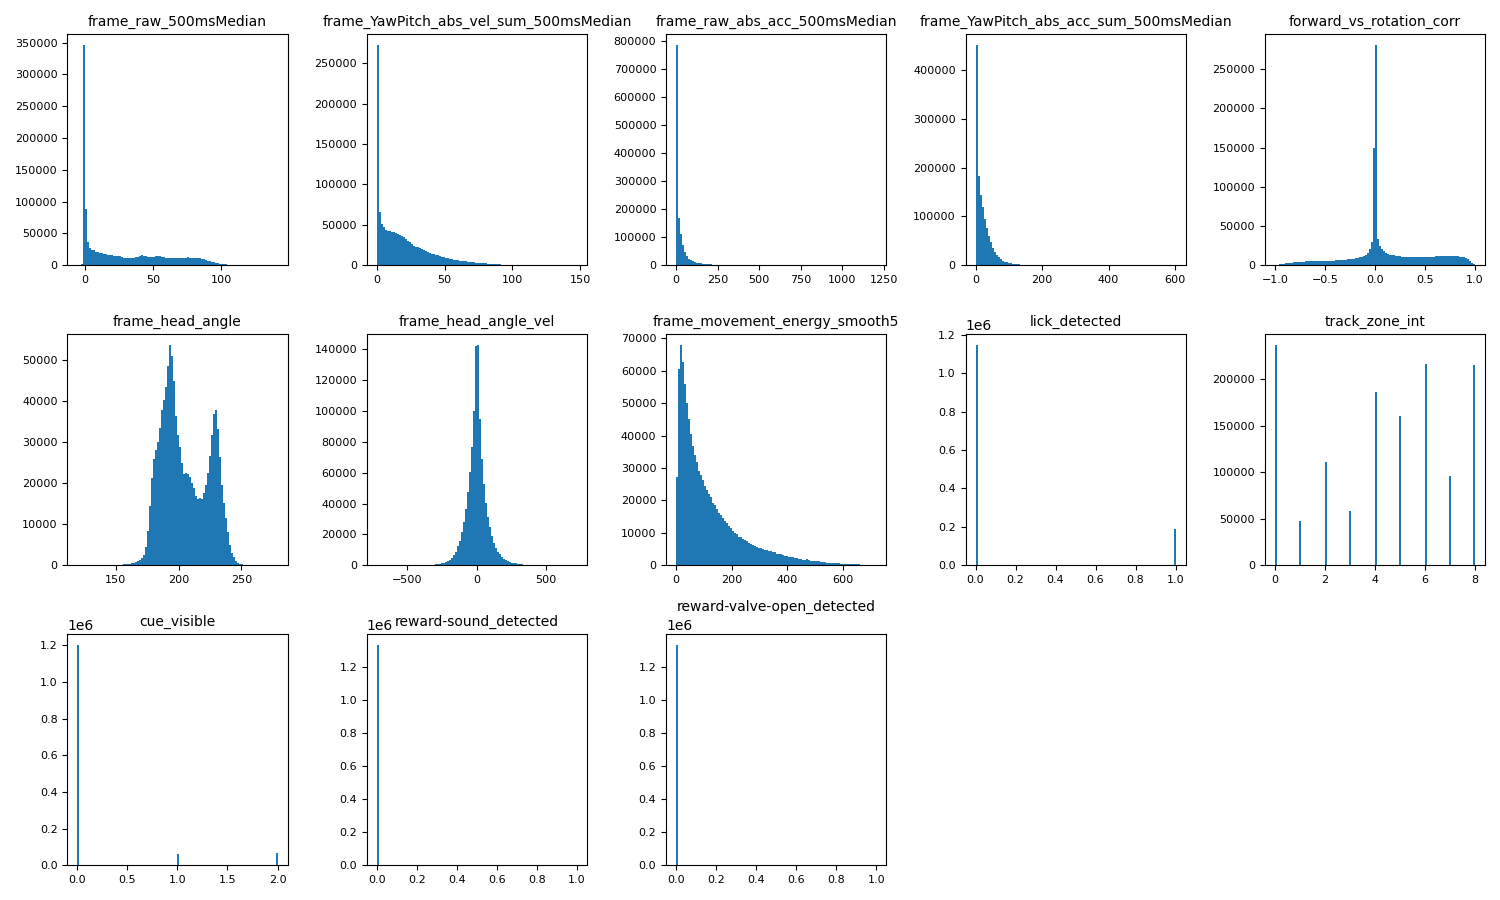

In [9]:
plt.close("all")
n_features = len(behavior_glm_input.columns)
n_cols = 5
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
axes = axes.flatten()  # Flatten to easily iterate

for i, col in enumerate(behavior_glm_input.columns):
    print(col)
    axes[i].hist(behavior_glm_input[col].dropna(), bins=100)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

# Hide extra subplots if any
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
session_ids = [x for x in range(8) if x in behavior_glm_input.index.unique(0)[:8]]
session_ids

[1, 2, 3, 4, 6, 7]

In [11]:
# more preprocessing
# Filter out rows with NaN values
nonan_mask = behavior_glm_input.notna().all(axis=1)
behavior_glm_input = behavior_glm_input[nonan_mask]

# first sessions (double rewards)
behavior_glm_input = behavior_glm_input.loc[session_ids]

# Drop highly correlated features (need to reassign or use inplace=True)
# correlated_features = ['frame_raw', 
#                        'frame_raw_quantile',
#                        'post_lick',
#                        'frame_abs_acceleration', 
#                        ]


# Only drop columns that actually exist in the dataframe
# existing_cols_to_drop = [col for col in correlated_features if col in behavior_glm_input.columns]
# behavior_glm_input = behavior_glm_input.drop(existing_cols_to_drop, axis=1)

# drop 'zone' columns
zone_columns = [col for col in behavior_glm_input.columns if 'zone_' in col]
behavior_glm_input = behavior_glm_input.drop(zone_columns, axis=1)

print(f"Final shape: {behavior_glm_input.shape}")
behavior_glm_input

Final shape: (175009, 12)


frame_raw_500msMedian  \
session_id entry_id                          
1          90                    69.195987   
           91                    70.260690   
           92                    71.913087   
           93                    73.130117   
           94                    74.616656   
...                                    ...   
7          38161                 71.013906   
           38162                 69.602951   
           38163                 69.262311   
           38164                 69.262311   
           38165                 69.262311   

                     frame_YawPitch_abs_vel_sum_500msMedian  \
session_id entry_id                                           
1          90                                     15.585511   
           91                                     15.926597   
           92                                     16.646956   
           93                                     17.936509   
           94                                     18.958000   
...                                                     ...   
7          38161                                  62.008449   
           38162                                  62.114451   
           38163                                  62.115298   
           38164                                  62.124197   
           38165                                  63.249910   

                     frame_raw_abs_acc_500msMedian  \
session_id entry_id                                  
1          90                         2.068807e+01   
           91                         4.152779e+01   
           92                         3.658733e+01   
           93                         2.873917e+01   
           94                         5.562355e+01   
...                                            ...   
7          38161                      3.074467e+01   
           38162                      3.128782e+01   
           38163                      1.515825e-13   
           38164                      0.000000e+00   
           38165                      0.000000e+00   

                     frame_YawPitch_abs_acc_sum_500msMedian  \
session_id entry_id                                           
1          90                                      9.886686   
           91                                      7.479334   
           92                                     27.594900   
           93                                     31.931599   
           94                                     24.587727   
...                                                     ...   
7          38161                                  12.066221   
           38162                                   2.355910   
           38163                                  17.241332   
           38164                                  52.172594   
           38165                                  47.849051   

                     forward_vs_rotation_corr  frame_head_angle  \
session_id entry_id                                               
1          90                        0.865337        197.096468   
           91                        0.864474        197.096468   
           92                        0.854175        198.264740   
           93                        0.859639        199.790068   
           94                        0.881153        204.017789   
...                                       ...               ...   
7          38161                    -0.638738        225.812044   
           38162                    -0.500967        226.743439   
           38163                    -0.298321        222.493073   
           38164                    -0.126831        222.493073   
           38165                    -0.020648        227.097687   

                     frame_head_angle_vel  frame_movement_energy_smooth5  \
session_id entry_id                                                        
1          90                 -385.014807              

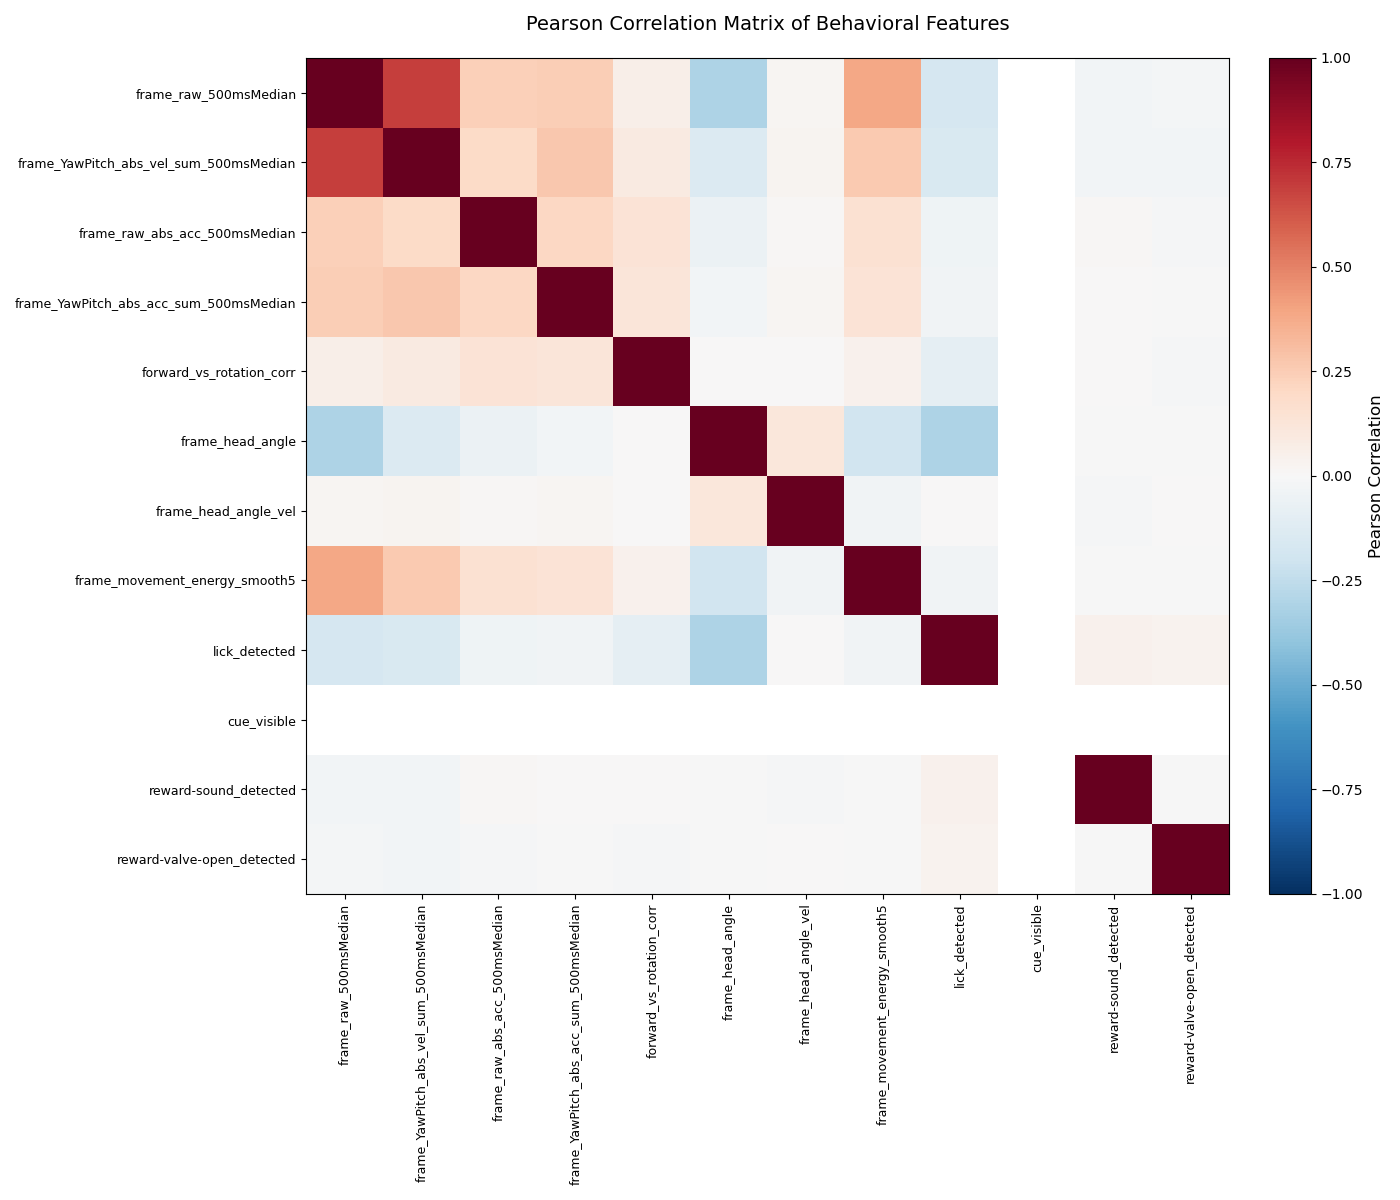


Correlation Matrix:
                                        frame_raw_500msMedian  \
frame_raw_500msMedian                                   1.000   
frame_YawPitch_abs_vel_sum_500msMedian                  0.691   
frame_raw_abs_acc_500msMedian                           0.242   
frame_YawPitch_abs_acc_sum_500msMedian                  0.250   
forward_vs_rotation_corr                                0.060   
frame_head_angle                                       -0.311   
frame_head_angle_vel                                    0.023   
frame_movement_energy_smooth5                           0.386   
lick_detected                                          -0.172   
cue_visible                                               NaN   
reward-sound_detected                                  -0.028   
reward-valve-open_detected                             -0.022   

                                        frame_YawPitch_abs_vel_sum_500msMedian  \
frame_raw_500msMedian                              

In [12]:
# Compute Pearson correlation matrix between all features
correlation_matrix = behavior_glm_input.corr(method='pearson')

# Create heatmap
plt.figure(figsize=(14, 12))
im = plt.imshow(correlation_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label('Pearson Correlation', fontsize=12)

# Set ticks and labels
feature_names = correlation_matrix.columns
plt.xticks(range(len(feature_names)), feature_names, rotation=90, fontsize=9)
plt.yticks(range(len(feature_names)), feature_names, fontsize=9)

# Add grid for better readability
plt.grid(False)

# Add title
plt.title('Pearson Correlation Matrix of Behavioral Features', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

# Optionally, print the correlation matrix
print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

In [13]:
# def add_joint_plot(fig, parent_spec, x, y, color='gray', alpha=0.01, share_x_with=None, share_y_with=None):
#     """Creates a joint scatter plot (no marginals) inside a subplot grid cell."""
#     # Convert to numpy arrays
#     x_np = np.array(x, dtype=np.float64) # behavior variable, regresser
#     y_np = np.array(y, dtype=np.float64) # firing rate
    
#     # Create mask for valid values
#     valid_mask = ~(np.isnan(x_np) | np.isnan(y_np))
#     x_clean = x_np[valid_mask]
#     y_clean = y_np[valid_mask]

#     # Create subplot and share axes if requested
#     gs = GridSpecFromSubplotSpec(1, 1, subplot_spec=parent_spec)
#     ax_joint = fig.add_subplot(gs[0, 0], sharex=share_x_with, sharey=share_y_with)

#     # Plot data, y the firing rate is on the x axis, x the behavior regresser is on the y axis
#     # add jitter to x for better visualization
#     # jitter_strength = 0.1 * (np.max(y_clean) - np.min(y_clean))
#     # y_jittered = y_clean + np.random.uniform(-jitter_strength, jitter_strength, size=y_clean.shape)
#     y_jittered = y_clean
#     ax_joint.scatter(y_jittered, x_clean, s=6, color=color, alpha=alpha)
    
#     # jitter the other
#     # jitter_strength = 0.05 * (np.max(x_clean) - np.min(x_clean))
#     # x_jittered = x_clean + np.random.uniform(-jitter_strength, jitter_strength, size=x_clean.shape)
#     x_jittered = x_clean
#     ax_joint.scatter(y_jittered, x_jittered, s=6, color=color, alpha=alpha)

#     # Turn off ticks
#     ax_joint.tick_params(labelleft=False, labelbottom=False)
#     [ax_joint.spines[side].set_visible(False) for side in ['top', 'right', 'left', 'bottom']]
    
#     return ax_joint

# # ==============================================================
# # === GLM FITTING AND VISUALIZATION ============================
# # ==============================================================

# def plot_neuron_session_histograms(behavior_aligned, ):
#     session_names = [f"S{s_id:02}" for s_id in behavior_aligned.index.unique('session_id')]
#     n_sessions = len(session_names)
#     n_regressers = behavior_aligned.shape[1]

#     # Create figure with specific layout
#     fig = plt.figure(figsize=(10 * n_regressers, 10 * n_regressers))
    
#     # Create GridSpec with extra row/column for histograms
#     outer_gs = plt.GridSpec(
#         nrows=n_regressers + 1, 
#         ncols=n_regressers + 1, 
#         figure=fig,
#         wspace=0.2, hspace=0.2,
#         width_ratios=[0.5] + [1]*n_regressers,  # Make first column narrower
#         height_ratios=[0.5] + [1]*n_regressers  # Make first row shorter
#     )

#     # === LEFT COLUMN: behavior histograms ===
#     left_hist_axes = []
#     for row, regr_name in enumerate(behavior_aligned.columns):
#         print(regr_name)
#         ax = fig.add_subplot(outer_gs[row + 1, 0])
#         left_hist_axes.append(ax)
#         regr_data = behavior_aligned[regr_name]
        
#         # Calculate density for consistent y-limits across row
#         counts, bins, _ = ax.hist(regr_data, bins=20, density=True, 
#                                 orientation="horizontal", color='gray', alpha=0.6)
        
#         ax.set_ylabel(f"{regr_name}", fontsize=13)
#         ax.set_xscale('log')
#         ax.grid(axis='x', linestyle='--', alpha=0.4)
#         [ax.spines[side].set_visible(False) for side in ['top', 'bottom', 'right']]
        
#         # Store density limits for sharing
#         ax.density_limits = (min(counts[counts > 0]), max(counts))
        
#         if row == n_regressers - 1:
#             ax.tick_params(labelsize=7, labelbottom=True)
#             ax.set_ylabel("Density", fontsize=6)
#         else:
#             plt.setp(ax.get_xticklabels(), visible=False)
            
#         # Reverse x-axis for better visualization
#         xlim = ax.get_xlim()
#         ax.set_xlim(xlim[1], xlim[0])

#     # === TOP ROW: behavior again ===
#     # === TOP ROW: behavior histograms ===
#     top_row_axes = []
#     shared_ylim = None
    
#     for col, regr_name in enumerate(behavior_aligned.columns):
#         ax = fig.add_subplot(outer_gs[0, col + 1])
#         top_row_axes.append(ax)
#         regr_data = behavior_aligned[regr_name]
        
#         # Calculate density with same bins as left column
#         counts, bins, _ = ax.hist(regr_data, bins=20, density=True, 
#                                 orientation="vertical", color='gray', alpha=0.6)
        
#         ax.set_xlabel(f"{regr_name}", fontsize=13)
#         ax.set_yscale('log')
#         ax.grid(axis='y', linestyle='--', alpha=0.4)
#         [ax.spines[side].set_visible(False) for side in ['top', 'right', 'left']]
        
#         # Share y limits across all top histograms
#         if shared_ylim is None:
#             shared_ylim = (min(counts[counts > 0]), max(counts))
#         ax.set_ylim(shared_ylim)
#         ax.set_title(f"{regr_name}", fontsize=10)
        
#         # Only show x ticks for rightmost histogram
#         if col == n_regressers - 1:
#             ax.tick_params(labelsize=7, labelleft=True)
#             ax.set_ylabel("Density", fontsize=6)
#         else:
#             plt.setp(ax.get_yticklabels(), visible=False)
    
#     # === MAIN GRID: joint plots ===
#     # get min and max of behavior_aligned for normalization
    
#     for row, regr_name in enumerate(behavior_aligned.columns):
#         print("Drawing regresser:", regr_name, '... ')
#         regr_data = behavior_aligned[regr_name].values
#         if len(regr_data) > 1_000:
#                 regr_data = np.random.choice(regr_data, size=1_000, replace=False)
#         for col, regr_name_2 in enumerate(behavior_aligned.columns):
#             regr_data_2 = behavior_aligned[regr_name_2].values
#             if len(regr_data_2) > 1_000:
#                 regr_data_2 = np.random.choice(regr_data_2, size=1_000, replace=False)
            
#             _ = add_joint_plot(fig, outer_gs[row + 1, col + 1], 
#                                regr_data, regr_data_2,
#                                share_x_with=top_row_axes[col],
#                                share_y_with=left_hist_axes[row])
#             # break
#         # break
#     fig.suptitle(f"Behavior regressers", fontsize=16)
        
#     # set left and right margin to 0.05
#     plt.subplots_adjust(left=0.05, right=0.95)
#     # plt.savefig(f"../outputs/glm_results/neuron_{neuron_i}_GLM.png", dpi=300)
#     plt.show()
#     # plt.close()

# plt.close("all")
# plot_neuron_session_histograms(behavior_glm_input)

In [14]:
beh = behavior_glm_input
beh

frame_raw_500msMedian  \
session_id entry_id                          
1          90                    69.195987   
           91                    70.260690   
           92                    71.913087   
           93                    73.130117   
           94                    74.616656   
...                                    ...   
7          38161                 71.013906   
           38162                 69.602951   
           38163                 69.262311   
           38164                 69.262311   
           38165                 69.262311   

                     frame_YawPitch_abs_vel_sum_500msMedian  \
session_id entry_id                                           
1          90                                     15.585511   
           91                                     15.926597   
           92                                     16.646956   
           93                                     17.936509   
           94                                     18.958000   
...                                                     ...   
7          38161                                  62.008449   
           38162                                  62.114451   
           38163                                  62.115298   
           38164                                  62.124197   
           38165                                  63.249910   

                     frame_raw_abs_acc_500msMedian  \
session_id entry_id                                  
1          90                         2.068807e+01   
           91                         4.152779e+01   
           92                         3.658733e+01   
           93                         2.873917e+01   
           94                         5.562355e+01   
...                                            ...   
7          38161                      3.074467e+01   
           38162                      3.128782e+01   
           38163                      1.515825e-13   
           38164                      0.000000e+00   
           38165                      0.000000e+00   

                     frame_YawPitch_abs_acc_sum_500msMedian  \
session_id entry_id                                           
1          90                                      9.886686   
           91                                      7.479334   
           92                                     27.594900   
           93                                     31.931599   
           94                                     24.587727   
...                                                     ...   
7          38161                                  12.066221   
           38162                                   2.355910   
           38163                                  17.241332   
           38164                                  52.172594   
           38165                                  47.849051   

                     forward_vs_rotation_corr  frame_head_angle  \
session_id entry_id                                               
1          90                        0.865337        197.096468   
           91                        0.864474        197.096468   
           92                        0.854175        198.264740   
           93                        0.859639        199.790068   
           94                        0.881153        204.017789   
...                                       ...               ...   
7          38161                    -0.638738        225.812044   
           38162                    -0.500967        226.743439   
           38163                    -0.298321        222.493073   
           38164                    -0.126831        222.493073   
           38165                    -0.020648        227.097687   

                     frame_head_angle_vel  frame_movement_energy_smooth5  \
session_id entry_id                                                        
1          90                 -385.014807              

In [15]:
# Install UMAP if needed (uncomment if not installed)
!pip install umap-learn

import umap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# ignore features
ign_features = [
    # 'trial_outcome',
    # 'cue',
    # 'choice_R1',
    # 'choice_R2',
    # 'global_t',
]
data_clean = beh.drop(columns=ign_features)

print(f"Data shape: {data_clean.shape}")
print(f"Number of features: {data_clean.shape[1]}")
print(f"Features: {data_clean.columns}")
print(f"Number of samples: {data_clean.shape[0]}")

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clean)

# PCA for comparison
print("\n=== PCA Analysis ===")
pca = PCA(n_components=min(10, data_clean.shape[1]))
pca_embedding = pca.fit_transform(data_scaled)

print(f"PCA explained variance ratio (first 3 components): {pca.explained_variance_ratio_[:3]}")
print(f"PCA cumulative variance (first 3 components): {np.cumsum(pca.explained_variance_ratio_[:3])[-1]:.3f}")
print(f"PCA cumulative variance (all components): {np.cumsum(pca.explained_variance_ratio_)}")

# UMAP embedding
print("\n=== UMAP Analysis ===")
print("Fitting UMAP (this may take a few minutes)...")
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=10,
    min_dist=0.1,
    metric='euclidean',
    random_state=41,
    verbose=True
)
umap_embedding = reducer.fit_transform(data_scaled)
print("UMAP fitting complete! Shape ", umap_embedding.shape)

# Create color mapping by session
session_colors = data_clean.index.get_level_values('session_id')
print(f"\nUnique sessions: {session_colors.unique()}")

Data shape: (175009, 12)
Number of features: 12
Features: Index(['frame_raw_500msMedian', 'frame_YawPitch_abs_vel_sum_500msMedian',
       'frame_raw_abs_acc_500msMedian',
       'frame_YawPitch_abs_acc_sum_500msMedian', 'forward_vs_rotation_corr',
       'frame_head_angle', 'frame_head_angle_vel',
       'frame_movement_energy_smooth5', 'lick_detected', 'cue_visible',
       'reward-sound_detected', 'reward-valve-open_detected'],
      dtype='object')
Number of samples: 175009

=== PCA Analysis ===
PCA explained variance ratio (first 3 components): [0.21217306 0.12480236 0.09770199]
PCA cumulative variance (first 3 components): 0.435
PCA cumulative variance (all components): [0.21217306 0.33697542 0.43467741 0.52700372 0.61724412 0.70565557
 0.78389436 0.85766406 0.92607156 0.97631583]

=== UMAP Analysis ===
Fitting UMAP (this may take a few minutes)...
UMAP(n_components=3, n_jobs=1, n_neighbors=10, random_state=41, verbose=True)


/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fri Feb 27 15:05:45 2026 Construct fuzzy simplicial set
Fri Feb 27 15:05:45 2026 Finding Nearest Neighbors
Fri Feb 27 15:05:45 2026 Building RP forest with 26 trees
Fri Feb 27 15:05:58 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	Stopping threshold met -- exiting after 2 iterations
Fri Feb 27 15:06:27 2026 Finished Nearest Neighbor Search
Fri Feb 27 15:06:32 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Fri Feb 27 15:09:05 2026 Finished embedding
UMAP fitting complete! Shape  (175009, 3)

Unique sessions: Index([1, 2, 3, 4, 6, 7], dtype='int64', name='session_id')


In [16]:
umap_embedding

array([[13.136962 ,  0.3906367,  6.705667 ],
       [13.127471 ,  0.3867149,  6.702747 ],
       [12.979586 , -1.8065568,  8.2596035],
       ...,
       [10.198133 , -2.5359259,  5.172863 ],
       [11.103147 , -1.9879414,  4.8493657],
       [10.721811 , -2.1050534,  4.4026976]],
      shape=(175009, 3), dtype=float32)

In [17]:

# Function to create 3D visualizations colored by specific features
def plot_umap_pca_colored_by(labels_dataframe, color_by=None, output_subdir='umap_pca_by_feature',
                             mask=None):
    """
    Create side-by-side UMAP and PCA 3D visualizations colored by specific features.
    
    Parameters:
    -----------
    labels_dataframe : pd.DataFrame
        DataFrame containing features/labels to color by. Must share index with embeddings.
    color_by : str, list, or None
        Feature name(s) to color by. If None, uses all columns. If list, iterates through all.
        If 'index', colors by the dataframe index.
    output_subdir : str
        Subdirectory name within output_dir to save HTML files.
    """
    import os
    
    # Create output directory
    viz_dir = f"{output_dir}{output_subdir}/"
    os.makedirs(viz_dir, exist_ok=True)
    
    # Determine which features to plot
    if color_by is None:
        features_to_plot = labels_dataframe.columns.tolist()
    elif color_by == 'index':
        features_to_plot = ['index']
    elif isinstance(color_by, str):
        features_to_plot = [color_by]
    elif isinstance(color_by, list):
        features_to_plot = color_by
    else:
        raise ValueError("color_by must be None, 'index', a string, or a list of strings")
    
    print(f"Creating visualizations for {len(features_to_plot)} features:\n{features_to_plot}\n")
    print(labels_dataframe.shape)
    print(umap_embedding.shape)
    # Create a visualization for each feature
    for feature in features_to_plot:
        print(f"Creating visualization for: {feature}")
        
        # Get feature values for coloring
        if feature == 'index':
            feature_values = labels_dataframe.index.get_level_values(0).values
            feature_name = 'Index'
        else:
            feature_values = labels_dataframe[feature].values
            feature_name = feature
        
        # Create figure with side-by-side 3D plots
        fig = make_subplots(
            rows=1, cols=2,
            subplot_titles=(f'UMAP 3D - colored by {feature_name}', 
                          f'PCA 3D - colored by {feature_name}'),
            specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
            horizontal_spacing=0.05
        )
        
        if mask is None:
            mask = np.ones_like(feature_values).astype(bool)
        
        # Add UMAP 3D scatter
        fig.add_trace(
            go.Scatter3d(
                x=umap_embedding[mask, 0],
                y=umap_embedding[mask, 1],
                z=umap_embedding[mask, 2],
                mode='markers',
                marker=dict(
                    size=2, 
                    color=feature_values[mask], 
                    colorscale='Viridis',
                    showscale=True, 
                    colorbar=dict(title=feature_name, x=0.46, len=0.8),
                    opacity=0.6
                ),
                text=[f'{feature_name}: {v:.2f}' if isinstance(v, (int, float)) else f'{feature_name}: {v}' 
                      for v in feature_values[mask]],
                hovertemplate='<b>%{text}</b><br>UMAP1: %{x:.2f}<br>UMAP2: %{y:.2f}<br>UMAP3: %{z:.2f}<extra></extra>'
            ),
            row=1, col=1
        )
        
        # Add PCA 3D scatter
        fig.add_trace(
            go.Scatter3d(
                x=pca_embedding[mask, 0],
                y=pca_embedding[mask, 1],
                z=pca_embedding[mask, 2],
                mode='markers',
                marker=dict(
                    size=2,
                    color=feature_values[mask],
                    colorscale='Viridis',
                    showscale=False,
                    opacity=0.6
                ),
                text=[f'{feature_name}: {v:.2f}' if isinstance(v, (int, float)) else f'{feature_name}: {v}' 
                      for v in feature_values[mask]],
                hovertemplate='<b>%{text}</b><br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>'
            ),
            row=1, col=2
        )
        
        # Update layout
        fig.update_layout(
            title_text=f'3D Embedding Comparison - Colored by {feature_name}',
            height=600,
            width=1400,
            showlegend=False,
            font=dict(size=10)
        )
        
        # Update scenes with labels
        fig.update_scenes(
            xaxis_title='Dimension 1',
            yaxis_title='Dimension 2',
            zaxis_title='Dimension 3',
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.3))
        )
        
        # Save to HTML
        sanitized_feature = feature_name.replace('/', '_').replace(' ', '_').replace(':', '_')
        html_file = f"{viz_dir}{sanitized_feature}_umap_pca_3d.html"
        fig.write_html(html_file)
        print(f"  ✓ Saved to: {html_file}")
    
    print(f"\n✓ All visualizations saved to: {viz_dir}")
    print(f"Total files created: {len(features_to_plot)}")
    
    return viz_dir



In [18]:
# check the general shape of clusters before moving on
plot_umap_pca_colored_by(data_clean, None, '.')

Creating visualizations for 12 features:
['frame_raw_500msMedian', 'frame_YawPitch_abs_vel_sum_500msMedian', 'frame_raw_abs_acc_500msMedian', 'frame_YawPitch_abs_acc_sum_500msMedian', 'forward_vs_rotation_corr', 'frame_head_angle', 'frame_head_angle_vel', 'frame_movement_energy_smooth5', 'lick_detected', 'cue_visible', 'reward-sound_detected', 'reward-valve-open_detected']

(175009, 12)
(175009, 3)
Creating visualization for: frame_raw_500msMedian
  ✓ Saved to: ./outputs/experimental/./frame_raw_500msMedian_umap_pca_3d.html
Creating visualization for: frame_YawPitch_abs_vel_sum_500msMedian
  ✓ Saved to: ./outputs/experimental/./frame_YawPitch_abs_vel_sum_500msMedian_umap_pca_3d.html
Creating visualization for: frame_raw_abs_acc_500msMedian
  ✓ Saved to: ./outputs/experimental/./frame_raw_abs_acc_500msMedian_umap_pca_3d.html
Creating visualization for: frame_YawPitch_abs_acc_sum_500msMedian
  ✓ Saved to: ./outputs/experimental/./frame_YawPitch_abs_acc_sum_500msMedian_umap_pca_3d.html
Cr

'./outputs/experimental/./'

In [19]:
# Create k-means clustering with k=9 and build comprehensive labels dataframe
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=8, covariance_type='full',
                                          random_state=42, n_init=3).fit(data_scaled)
cluster_labels = gmm.predict(data_scaled)


In [20]:

print("=== Creating Labels Dataframe ===\n")

# Create labels dataframe starting with cluster assignments
labels_df = pd.DataFrame({'gmm_cluster': cluster_labels}, index=data_clean.index)

# Add the previously dropped behavioral features
for feat in ign_features:
    if feat in beh.columns:
        labels_df[feat] = beh.loc[:, feat]
        print(f"Added feature: {feat}")

print(f"\n✓ Labels dataframe created with shape: {labels_df.shape}")
print(f"✓ Columns: {list(labels_df.columns)}")
(labels_df)


=== Creating Labels Dataframe ===


✓ Labels dataframe created with shape: (175009, 1)
✓ Columns: ['gmm_cluster']


gmm_cluster
session_id entry_id             
1          90                  0
           91                  0
           92                  0
           93                  0
           94                  0
...                          ...
7          38161               2
           38162               2
           38163               2
           38164               2
           38165               2

[175009 rows x 1 columns]

In [21]:
plt.hist(labels_df['gmm_cluster'], bins=np.arange(-0.5, 8 + 1.5, 1), rwidth=0.8)
plt.xlabel("GMM Cluster")
plt.ylabel("Count")

Text(19.88888888888889, 0.5, 'Count')

In [22]:
fr_first7 = fr[nonan_mask.values].loc[:7]
fr_first7

Unit0001  Unit0002  Unit0003  Unit0004  \
session_id session_t  global_t                                             
1          3640000    3640000            0         0         0         0   
           3680000    3680000           25         0         0         0   
           3720000    3720000            0         0         0         0   
           3760000    3760000            0         0         0         0   
           3800000    3800000            0         0         0         0   
...                                    ...       ...       ...       ...   
7          1526480000 8962080000         0         0         0         0   
           1526520000 8962120000         0        25         0         0   
           1526560000 8962160000         0         0         0         0   
           1526600000 8962200000         0        25         0         0   
           1526640000 8962240000         0         0         0         0   

                                  Unit0005  Unit0006  Unit0007  Unit0008  \
session_id session_t  global_t                                             
1          3640000    3640000            0         0         0         0   
           3680000    3680000            0         0         0         0   
           3720000    3720000            0         0         0         0   
           3760000    3760000            0         0         0         0   
           3800000    3800000            0         0         0         0   
...                                    ...       ...       ...       ...   
7          1526480000 8962080000         0         0         0         0   
           1526520000 8962120000         0         0        25         0   
           1526560000 8962160000         0         0         0         0   
           1526600000 8962200000         0         0         0         0   
           1526640000 8962240000         0         0         0         0   

                                  Unit0009  Unit0010  ...  Unit0068  Unit0069  \
session_id session_t  global_t                        ...                       
1          3640000    3640000            0         0  ...         0         0   
           3680000    3680000            0         0  ...         0         0   
           3720000    3720000            0         0  ...         0         0   
           3760000    3760000            0         0  ...         0        25   
           3800000    3800000            0         0  ...         0        25   
...                                    ...       ...  ...       ...       ...   
7          1526480000 8962080000         0         0  ...         0         0   
           1526520000 8962120000         0         0  ...         0        50   
           1526560000 8962160000         0         0  ...         0         0   
           1526600000 8962200000         0         0  ...         0         0   
           1526640000 8962240000         0         0  ...         0         0   

                                  Unit0070  Unit0071  Unit0072  Unit0073  \
session_id session_t  global_t                                             
1          3640000    3640000            0         0         0         0   
           3680000    3680000            0         0         0         0   
           3720000    3720000            0         0        25         0   
           3760000    3760000            0         0         0         0   
           3800000    3800000            0         0        25         0   
...                                    ...       ...       ...       ...   
7          1526480000 8962080000         0         0         0         0   
           1526520000 8962120000        25         0         0         0   
           1526560000 8962160000         0         0        25         0   
           1526600000 8962200000         0         0         0         0   
           1526640000 8962240000         0         0         0         0   

             

In [23]:

# mask = fr_first7['Unit0015'] > 50
target_unit = 'Unit0038'
mask = fr_first7[target_unit] > np.percentile(fr_first7[target_unit], 90)
plot_umap_pca_colored_by(fr_first7, color_by=target_unit, output_subdir='umap_neuron_labels', mask=mask)
fr_first7

Creating visualizations for 1 features:
['Unit0038']

(175009, 77)
(175009, 3)
Creating visualization for: Unit0038
  ✓ Saved to: ./outputs/experimental/umap_neuron_labels/Unit0038_umap_pca_3d.html

✓ All visualizations saved to: ./outputs/experimental/umap_neuron_labels/
Total files created: 1


Unit0001  Unit0002  Unit0003  Unit0004  \
session_id session_t  global_t                                             
1          3640000    3640000            0         0         0         0   
           3680000    3680000           25         0         0         0   
           3720000    3720000            0         0         0         0   
           3760000    3760000            0         0         0         0   
           3800000    3800000            0         0         0         0   
...                                    ...       ...       ...       ...   
7          1526480000 8962080000         0         0         0         0   
           1526520000 8962120000         0        25         0         0   
           1526560000 8962160000         0         0         0         0   
           1526600000 8962200000         0        25         0         0   
           1526640000 8962240000         0         0         0         0   

                                  Unit0005  Unit0006  Unit0007  Unit0008  \
session_id session_t  global_t                                             
1          3640000    3640000            0         0         0         0   
           3680000    3680000            0         0         0         0   
           3720000    3720000            0         0         0         0   
           3760000    3760000            0         0         0         0   
           3800000    3800000            0         0         0         0   
...                                    ...       ...       ...       ...   
7          1526480000 8962080000         0         0         0         0   
           1526520000 8962120000         0         0        25         0   
           1526560000 8962160000         0         0         0         0   
           1526600000 8962200000         0         0         0         0   
           1526640000 8962240000         0         0         0         0   

                                  Unit0009  Unit0010  ...  Unit0068  Unit0069  \
session_id session_t  global_t                        ...                       
1          3640000    3640000            0         0  ...         0         0   
           3680000    3680000            0         0  ...         0         0   
           3720000    3720000            0         0  ...         0         0   
           3760000    3760000            0         0  ...         0        25   
           3800000    3800000            0         0  ...         0        25   
...                                    ...       ...  ...       ...       ...   
7          1526480000 8962080000         0         0  ...         0         0   
           1526520000 8962120000         0         0  ...         0        50   
           1526560000 8962160000         0         0  ...         0         0   
           1526600000 8962200000         0         0  ...         0         0   
           1526640000 8962240000         0         0  ...         0         0   

                                  Unit0070  Unit0071  Unit0072  Unit0073  \
session_id session_t  global_t                                             
1          3640000    3640000            0         0         0         0   
           3680000    3680000            0         0         0         0   
           3720000    3720000            0         0        25         0   
           3760000    3760000            0         0         0         0   
           3800000    3800000            0         0        25         0   
...                                    ...       ...       ...       ...   
7          1526480000 8962080000         0         0         0         0   
           1526520000 8962120000        25         0         0         0   
           1526560000 8962160000         0         0        25         0   
           1526600000 8962200000         0         0         0         0   
           1526640000 8962240000         0         0         0         0   

             

In [24]:
# plot_umap_pca_colored_by(labels_df, color_by=None, output_subdir='umap_trialwise_labels')

plot_umap_pca_colored_by(data_clean, color_by=None, output_subdir='umap_fitted_labels')


Creating visualizations for 12 features:
['frame_raw_500msMedian', 'frame_YawPitch_abs_vel_sum_500msMedian', 'frame_raw_abs_acc_500msMedian', 'frame_YawPitch_abs_acc_sum_500msMedian', 'forward_vs_rotation_corr', 'frame_head_angle', 'frame_head_angle_vel', 'frame_movement_energy_smooth5', 'lick_detected', 'cue_visible', 'reward-sound_detected', 'reward-valve-open_detected']

(175009, 12)
(175009, 3)
Creating visualization for: frame_raw_500msMedian
  ✓ Saved to: ./outputs/experimental/umap_fitted_labels/frame_raw_500msMedian_umap_pca_3d.html
Creating visualization for: frame_YawPitch_abs_vel_sum_500msMedian
  ✓ Saved to: ./outputs/experimental/umap_fitted_labels/frame_YawPitch_abs_vel_sum_500msMedian_umap_pca_3d.html
Creating visualization for: frame_raw_abs_acc_500msMedian
  ✓ Saved to: ./outputs/experimental/umap_fitted_labels/frame_raw_abs_acc_500msMedian_umap_pca_3d.html
Creating visualization for: frame_YawPitch_abs_acc_sum_500msMedian
  ✓ Saved to: ./outputs/experimental/umap_fitt

'./outputs/experimental/umap_fitted_labels/'

session_id  session_t   global_t  
1           3640000     3640000      -0.227875
            3680000     3680000      -0.227875
            3720000     3720000      -0.227875
            3760000     3760000      -0.227875
            3800000     3800000      -0.227875
                                        ...   
7           1526480000  8962080000   -0.227875
            1526520000  8962120000   -0.227875
            1526560000  8962160000   -0.227875
            1526600000  8962200000   -0.227875
            1526640000  8962240000   -0.227875
Name: Unit0038, Length: 175009, dtype: float64
0 -0.22787505281970857
1 -0.22787505281970857
2 -0.22787505281970857
3 -0.22787505281970857
4 -0.22787505281970857
5 -0.22787505281970857
6 -0.22787505281970857
7 -0.22787505281970857


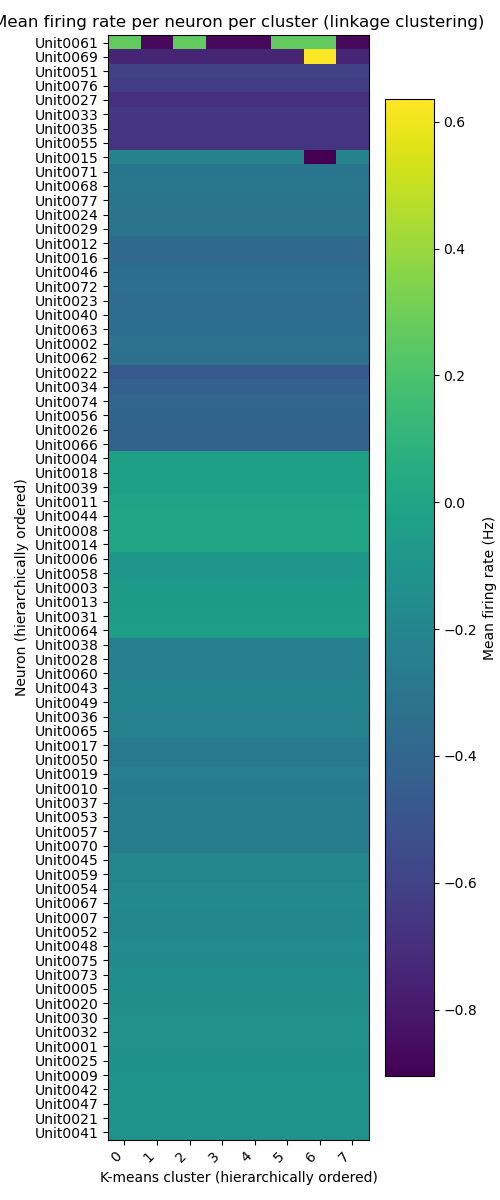

array([0, 1, 2, 3, 4, 5, 6, 7])

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist


cluster_ids = np.sort(labels_df.gmm_cluster.unique())
neurons = fr_first7.columns

# Preallocate: rows = neurons, cols = clusters
heatmap = np.zeros((len(neurons), len(cluster_ids)))

for n, unit_col in enumerate(neurons):
    fr_unit = fr_first7[unit_col]
    if (fr_unit == 0).all():
        continue
    # zscore
    fr_unit = (fr_unit-fr_unit.mean()) /fr_unit.std()
    if unit_col == target_unit:
        print(fr_unit)

    for j, cid in enumerate(cluster_ids):
        cluster_mask = labels_df.gmm_cluster == cid
        heatmap[n, j] = fr_unit[cluster_mask.values].median()
        if unit_col == target_unit:
            print(cid, fr_unit[cluster_mask.values].median())

row_dist = pdist(heatmap, metric="euclidean")
row_linkage = linkage(row_dist, method="average")
row_order = leaves_list(row_linkage)

# col_dist = pdist(heatmap.T, metric="euclidean")
# col_linkage = linkage(col_dist, method="average")
# col_order = leaves_list(col_linkage)

heatmap_ord = heatmap[row_order]#[:, col_order]
neurons_ord = neurons[row_order]
cluster_ids_ord = cluster_ids# [col_order]


plt.figure(figsize=((.6 * len(cluster_ids_ord) + 1) // 1, (1 + 0.15 * len(neurons_ord)) // 1))

im = plt.imshow(
    heatmap_ord,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    norm=Normalize(
        vmin=np.nanmin(heatmap_ord),
        vmax=np.nanmax(heatmap_ord)
    )
)

plt.colorbar(im, label="Mean firing rate (Hz)")

plt.xticks(
    ticks=np.arange(len(cluster_ids_ord)),
    labels=cluster_ids_ord,
    rotation=45,
    ha="right"
)
plt.yticks(
    ticks=np.arange(len(neurons_ord)),
    labels=neurons_ord
)

plt.xlabel("K-means cluster (hierarchically ordered)")
plt.ylabel("Neuron (hierarchically ordered)")
plt.title("Mean firing rate per neuron per cluster (linkage clustering)")

plt.tight_layout()
plt.show()
cluster_ids_ord

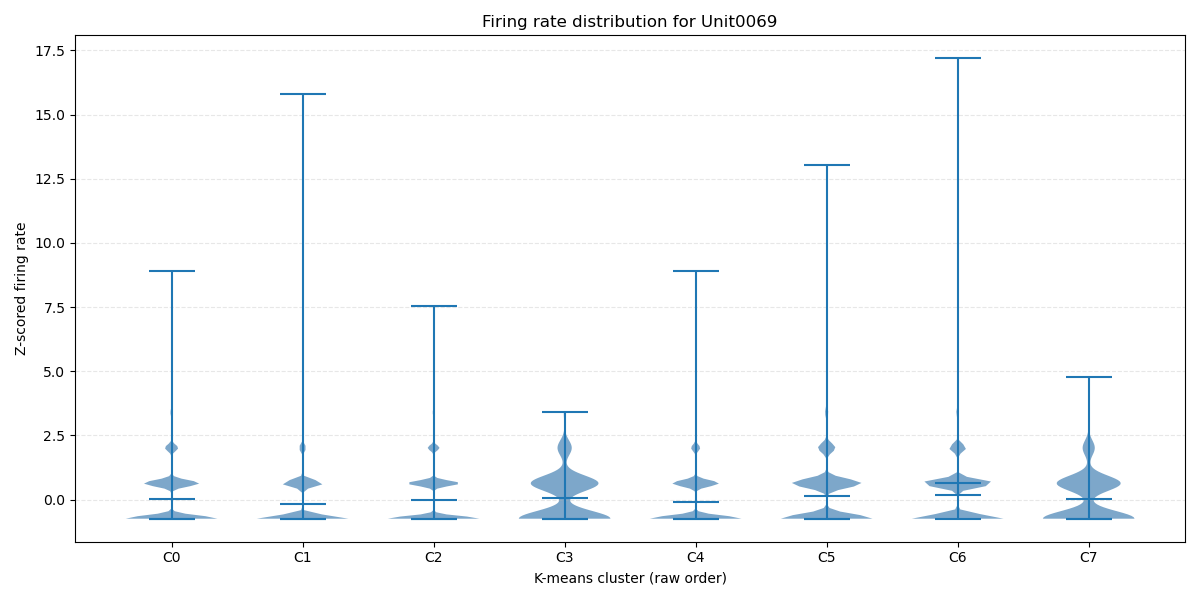


=== Unit0069 Statistics by Cluster ===
Cluster 0: mean=0.02, median=-0.74, std=1.01, n=32596
Cluster 1: mean=-0.16, median=-0.74, std=0.88, n=15564
Cluster 2: mean=-0.02, median=-0.74, std=0.98, n=71738
Cluster 3: mean=0.05, median=-0.74, std=0.94, n=308
Cluster 4: mean=-0.10, median=-0.74, std=0.91, n=22468
Cluster 5: mean=0.16, median=-0.74, std=1.10, n=9145
Cluster 6: mean=0.16, median=0.64, std=1.12, n=22884
Cluster 7: mean=0.01, median=-0.74, std=0.93, n=306


In [32]:
import numpy as np
import matplotlib.pyplot as plt

neuron_id = 68
neuron_col = fr_first7.columns[neuron_id]

fr_neuron = fr_first7[neuron_col]

# z-score identically to heatmap
fr_neuron = (fr_neuron - fr_neuron.mean()) / fr_neuron.std()

cluster_data = []
cluster_labels = []

for cid in np.sort(labels_df.gmm_cluster.unique()):
    cluster_mask = labels_df.gmm_cluster == cid
    cluster_fr = fr_neuron[cluster_mask.values]
    cluster_data.append(cluster_fr)
    cluster_labels.append(f"C{cid}")

plt.figure(figsize=(12, 6))

parts = plt.violinplot(
    cluster_data,
    positions=np.arange(len(cluster_labels)),
    showmeans=True,
    showmedians=True,
    widths=0.7
)

for pc in parts['bodies']:
    pc.set_facecolor('steelblue')
    pc.set_alpha(0.7)

plt.xticks(np.arange(len(cluster_labels)), cluster_labels)
plt.xlabel("K-means cluster (raw order)")
plt.ylabel("Z-scored firing rate")
plt.title(f"Firing rate distribution for {neuron_col}")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n=== {neuron_col} Statistics by Cluster ===")
for cid in np.sort(labels_df.gmm_cluster.unique()):
    cluster_mask = labels_df.gmm_cluster == cid
    cluster_fr = fr_neuron[cluster_mask.values]
    print(
        f"Cluster {cid}: "
        f"mean={cluster_fr.mean():.2f}, "
        f"median={cluster_fr.median():.2f}, "
        f"std={cluster_fr.std():.2f}, "
        f"n={len(cluster_fr)}"
    )


In [27]:
# ORDER OF THIS IS WRONG? CLUSTER IDS SOMEHOW MIXED UP BETWEEN HEATMAP AND VIOLIN PLOTS

In [28]:
# # confirm that t- events are in the right region using bodycam

# camera = 'bodycam'
# plt.close("all")
# for s_id in t0_events.index.unique('session_id'):
#     if s_id <8:
#         continue
    
#     data = session_modality_from_nas(session_dirs[s_id], f"{camera}_packages")
#     for t0 in t0_events.loc[s_id].index[::19]:
#         print(t0_events.loc[s_id, t0])
        
#         fig, axes = plt.subplots(ncols=6, figsize=(20,3))
#         fig.suptitle(f'Session {s_id}, t0: {t0}', fontsize=16)
#         for i, delta in enumerate(range(-12, 12, 4)):
#             closest_frame = data.iloc[(data[f'{camera}_image_ephys_timestamp'] - t0).abs().argsort()[0] +delta]
#             frame_id = int(closest_frame.loc[f'{camera}_image_id']) 
#             ephys_t = closest_frame.loc[f'{camera}_image_ephys_timestamp'] + (delta * 40000)
            
#             closest_beh_t = (behavior.xs(s_id, level='session_id').loc[:, 'from_ephys_timestamp'] - ephys_t).abs().argsort().values[0]
#             closest_beh_frame = behavior.xs(s_id, level='session_id').iloc[closest_beh_t]
            
#             # print(f"Frame id: {frame_id}, ephys time: {ephys_t}, closest behavior time: {closest_beh_t}, frame position: {closest_beh_frame['frame_position']}")
#             # print(f"Looking for t0: {t0}, closest frame id: {frame_id}, ephys time: {ephys_t}, diff: {ephys_t - t0}")
#             # print(f"Position at t0: {t0_events.loc[(s_id, t0), 'x_position']}")
#             title = f'x: {closest_beh_frame['frame_position']:.2f}cm, \nt_diff: {(ephys_t - t0)/1e6:.3f} us, \ndelta={delta}'
            
#             frame_key = f'frame_{frame_id:06d}'

#             img = session_modality_from_nas(session_dirs[s_id], key=f"{camera}_frames", columns=[frame_key])
#             axes[i].imshow(img[0])
#             axes[i].axis('off')
#             axes[i].set_title(title, fontsize=8)
        
#         plt.tight_layout()
#         plt.show()
#         # break
#     break
        

In [29]:
neurons_ord

Index(['Unit0061', 'Unit0069', 'Unit0051', 'Unit0076', 'Unit0027', 'Unit0033',
       'Unit0035', 'Unit0055', 'Unit0015', 'Unit0071', 'Unit0068', 'Unit0077',
       'Unit0024', 'Unit0029', 'Unit0012', 'Unit0016', 'Unit0046', 'Unit0072',
       'Unit0023', 'Unit0040', 'Unit0063', 'Unit0002', 'Unit0062', 'Unit0022',
       'Unit0034', 'Unit0074', 'Unit0056', 'Unit0026', 'Unit0066', 'Unit0004',
       'Unit0018', 'Unit0039', 'Unit0011', 'Unit0044', 'Unit0008', 'Unit0014',
       'Unit0006', 'Unit0058', 'Unit0003', 'Unit0013', 'Unit0031', 'Unit0064',
       'Unit0038', 'Unit0028', 'Unit0060', 'Unit0043', 'Unit0049', 'Unit0036',
       'Unit0065', 'Unit0017', 'Unit0050', 'Unit0019', 'Unit0010', 'Unit0037',
       'Unit0053', 'Unit0057', 'Unit0070', 'Unit0045', 'Unit0059', 'Unit0054',
       'Unit0067', 'Unit0007', 'Unit0052', 'Unit0048', 'Unit0075', 'Unit0073',
       'Unit0005', 'Unit0020', 'Unit0030', 'Unit0032', 'Unit0001', 'Unit0025',
       'Unit0009', 'Unit0042', 'Unit0047', 'Unit0021

In [30]:
import os

output_dir = "./outputs/glm_input_data/"

# Save behavior and spikes dataframes as npy files

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Save behavior dataframe
behavior_file = os.path.join(output_dir, 'behavior_glm_input.npy')
np.save(behavior_file, behavior_glm_input.values)
print(f"✓ Saved behavior data to: {behavior_file}")

# Save behavior index information
behavior_index_file = os.path.join(output_dir, 'behavior_glm_input_index.npy')
np.save(behavior_index_file, behavior_glm_input.index.values)
print(f"✓ Saved behavior index to: {behavior_index_file}")

# Save behavior column names
behavior_columns_file = os.path.join(output_dir, 'behavior_glm_input_columns.npy')
np.save(behavior_columns_file, np.array(behavior_glm_input.columns, dtype=object))
print(f"✓ Saved behavior columns to: {behavior_columns_file}")

# Save spikes (firing rate) dataframe
spikes_file = os.path.join(output_dir, 'fr_first7.npy')
np.save(spikes_file, fr_first7.values)
print(f"✓ Saved spikes data to: {spikes_file}")

# Save spikes index information
spikes_index_file = os.path.join(output_dir, 'fr_first7_index.npy')
np.save(spikes_index_file, fr_first7.index.values)
print(f"✓ Saved spikes index to: {spikes_index_file}")

# Save spikes column names (neuron IDs)
spikes_columns_file = os.path.join(output_dir, 'fr_first7_columns.npy')
np.save(spikes_columns_file, np.array(fr_first7.columns, dtype=object))
print(f"✓ Saved spikes columns to: {spikes_columns_file}")

# Save full firing rate dataframe
fr_full_file = os.path.join(output_dir, 'fr_full.npy')
np.save(fr_full_file, fr.values)
print(f"✓ Saved full firing rate data to: {fr_full_file}")

# Save full fr index information
fr_full_index_file = os.path.join(output_dir, 'fr_full_index.npy')
np.save(fr_full_index_file, fr.index.values)
print(f"✓ Saved full fr index to: {fr_full_index_file}")

# Save full fr column names (neuron IDs)
fr_full_columns_file = os.path.join(output_dir, 'fr_full_columns.npy')
np.save(fr_full_columns_file, np.array(fr.columns, dtype=object))
print(f"✓ Saved full fr columns to: {fr_full_columns_file}")

print(f"\n✓ All files saved to: {output_dir}")

✓ Saved behavior data to: ./outputs/glm_input_data/behavior_glm_input.npy
✓ Saved behavior index to: ./outputs/glm_input_data/behavior_glm_input_index.npy
✓ Saved behavior columns to: ./outputs/glm_input_data/behavior_glm_input_columns.npy
✓ Saved spikes data to: ./outputs/glm_input_data/fr_first7.npy
✓ Saved spikes index to: ./outputs/glm_input_data/fr_first7_index.npy
✓ Saved spikes columns to: ./outputs/glm_input_data/fr_first7_columns.npy
✓ Saved full firing rate data to: ./outputs/glm_input_data/fr_full.npy
✓ Saved full fr index to: ./outputs/glm_input_data/fr_full_index.npy
✓ Saved full fr columns to: ./outputs/glm_input_data/fr_full_columns.npy

✓ All files saved to: ./outputs/glm_input_data/
